<a href="https://colab.research.google.com/github/positivefunctionIN/Medical_Imaging_using_CNN/blob/main/Medical_Imaging_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
!pip install kaggle -q #Intialization

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from google.colab import files

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [7]:
import os   #using API token
os.environ["KAGGLE_API_TOKEN"] = "KGAT_5b435f7615b49cc51191f5ab984c36d2"

In [8]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip -q chest-xray-pneumonia.zip -d chest_xray_data

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:23<00:00, 106MB/s]



In [9]:
data_path = "/content/chest_xray_data/chest_xray"

In [10]:
print("Dataset structure:")
print("Train:", os.listdir(f"{data_path}/train"))
print("Test:", os.listdir(f"{data_path}/test"))
print("Val:", os.listdir(f"{data_path}/val"))

Dataset structure:
Train: ['NORMAL', 'PNEUMONIA']
Test: ['NORMAL', 'PNEUMONIA']
Val: ['NORMAL', 'PNEUMONIA']


In [11]:
train_normal = len(os.listdir(f"{data_path}/train/NORMAL"))
train_pneumonia = len(os.listdir(f"{data_path}/train/PNEUMONIA"))
test_normal = len(os.listdir(f"{data_path}/test/NORMAL"))
test_pneumonia = len(os.listdir(f"{data_path}/test/PNEUMONIA"))

print(f"\n📊 Training set:")
print(f"   Normal: {train_normal}")
print(f"   Pneumonia: {train_pneumonia}")
print(f"\n📊 Test set:")
print(f"   Normal: {test_normal}")
print(f"   Pneumonia: {test_pneumonia}")


📊 Training set:
   Normal: 1341
   Pneumonia: 3875

📊 Test set:
   Normal: 234
   Pneumonia: 390


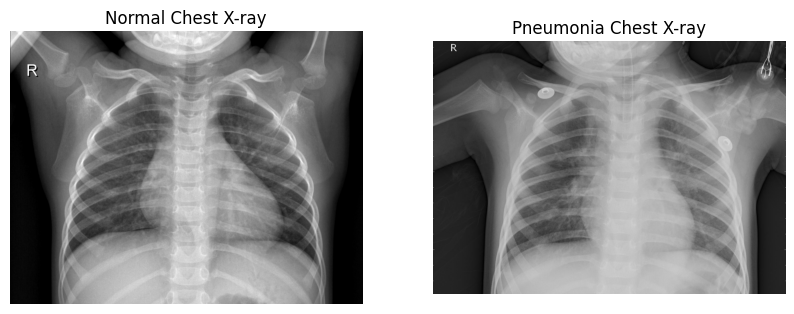

✅ Dataset explored


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

normal_sample = plt.imread(f"{data_path}/train/NORMAL/" + os.listdir(f"{data_path}/train/NORMAL")[0])
pneumonia_sample = plt.imread(f"{data_path}/train/PNEUMONIA/" + os.listdir(f"{data_path}/train/PNEUMONIA")[0])

axes[0].imshow(normal_sample, cmap='gray')
axes[0].set_title("Normal Chest X-ray")
axes[0].axis('off')

axes[1].imshow(pneumonia_sample, cmap='gray')
axes[1].set_title("Pneumonia Chest X-ray")
axes[1].axis('off')

plt.show()
print("✅ Dataset explored")


In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

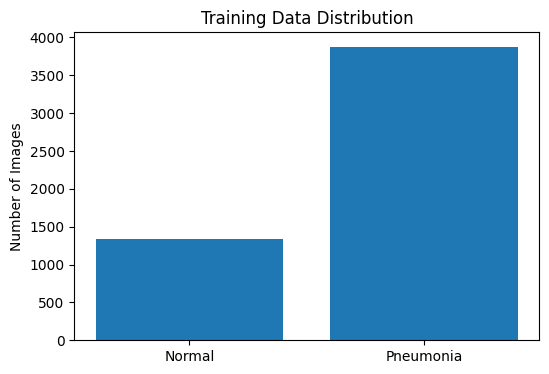

In [14]:
labels = ['Normal', 'Pneumonia']
counts = [train_normal, train_pneumonia]

plt.figure(figsize=(6,4))
plt.bar(labels, counts)
plt.title("Training Data Distribution")
plt.ylabel("Number of Images")
plt.show()

In [15]:
train_generator = train_datagen.flow_from_directory(
    f"{data_path}/train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    f"{data_path}/train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    f"{data_path}/test",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [16]:
print(train_generator.class_indices)

{'NORMAL': 0, 'PNEUMONIA': 1}


In [17]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D

In [18]:
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [19]:
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,038,529 (26.85 MB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [20]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [21]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 180s 1s/step - accuracy: 0.7726 - loss: 0.4892 - val_accuracy: 0.8907 - val_loss: 0.2650
Epoch 2/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 108s 827ms/step - accuracy: 0.8708 - loss: 0.3005 - val_accuracy: 0.9195 - val_loss: 0.2277
Epoch 3/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 108s 829ms/step - accuracy: 0.8804 - loss: 0.2696 - val_accuracy: 0.9262 - val_loss: 0.1990
Epoch 4/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 107s 821ms/step - accuracy: 0.8948 - loss: 0.2510 - val_accuracy: 0.9348 - val_loss: 0.1748
Epoch 5/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 111s 849ms/step - accuracy: 0.9070 - loss: 0.2245 - val_accuracy: 0.9377 - val_loss: 0.1749


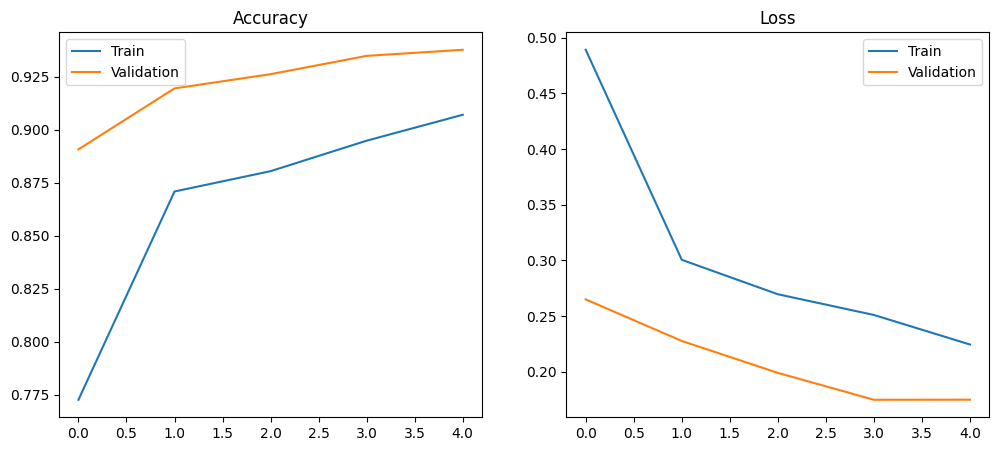

In [22]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(['Train','Validation'])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(['Train','Validation'])

plt.show()

In [23]:
model.save("pneumonia_densenet.keras")

In [24]:
history.history['val_accuracy'][-1]

0.9376797676086426

In [25]:
model.evaluate(test_generator)

20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 960ms/step - accuracy: 0.8526 - loss: 0.3337


[0.3336840271949768, 0.8525640964508057]

In [26]:
import os

project_path = "/content/drive/MyDrive/Medical_Xray_Project"

folders = [
    "datasets",
    "models",
    "outputs",
    "reports",
    "app"
]

for folder in folders:
    os.makedirs(os.path.join(project_path, folder), exist_ok=True)

print("✅ Project folder created successfully!")

✅ Project folder created successfully!


In [27]:
model.save("/content/drive/MyDrive/Medical_Xray_Project/models/pneumonia_densenet.keras")

print("✅ Model saved successfully.")

✅ Model saved successfully.


In [28]:
predictions = model.predict(test_generator)

predicted_classes = (predictions > 0.5).astype(int).flatten()

true_classes = test_generator.classes

class_labels = list(test_generator.class_indices.keys())

20/20 ━━━━━━━━━━━━━━━━━━━━ 32s 879ms/step


In [29]:
from sklearn.metrics import classification_report

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
))

              precision    recall  f1-score   support

      NORMAL       0.92      0.66      0.77       234
   PNEUMONIA       0.83      0.97      0.89       390

    accuracy                           0.85       624
   macro avg       0.87      0.81      0.83       624
weighted avg       0.86      0.85      0.85       624



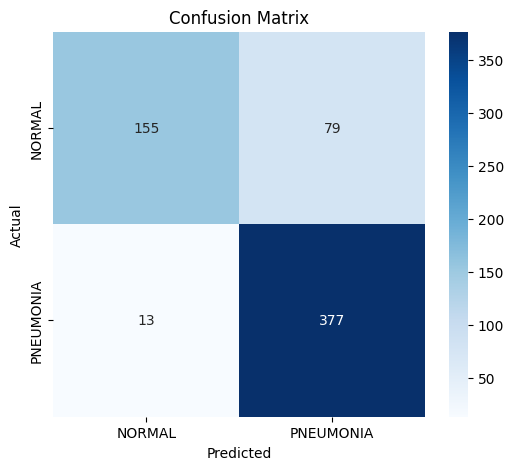

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

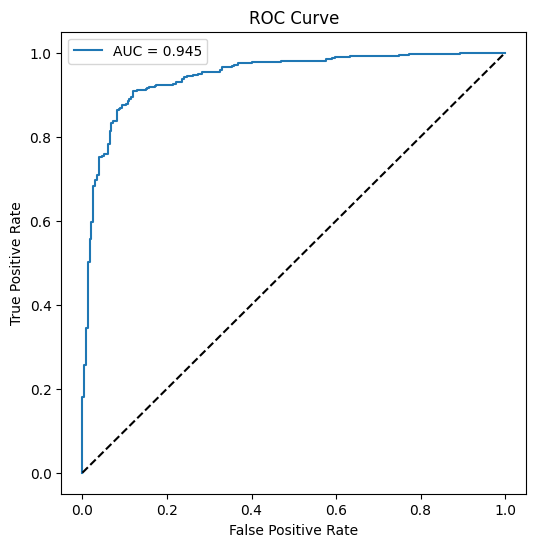

In [31]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(true_classes, predictions)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [32]:
test_generator.reset()

In [33]:
images, labels = next(test_generator)

In [34]:
predictions = model.predict(images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 16s 16s/step


In [35]:
predicted_labels = (predictions > 0.5).astype(int).flatten()

In [36]:
confidence_scores = np.where(
    predicted_labels == 1,
    predictions.flatten(),
    1 - predictions.flatten()
)

In [37]:
class_mode='binary'

In [38]:
true_labels = labels.astype(int)

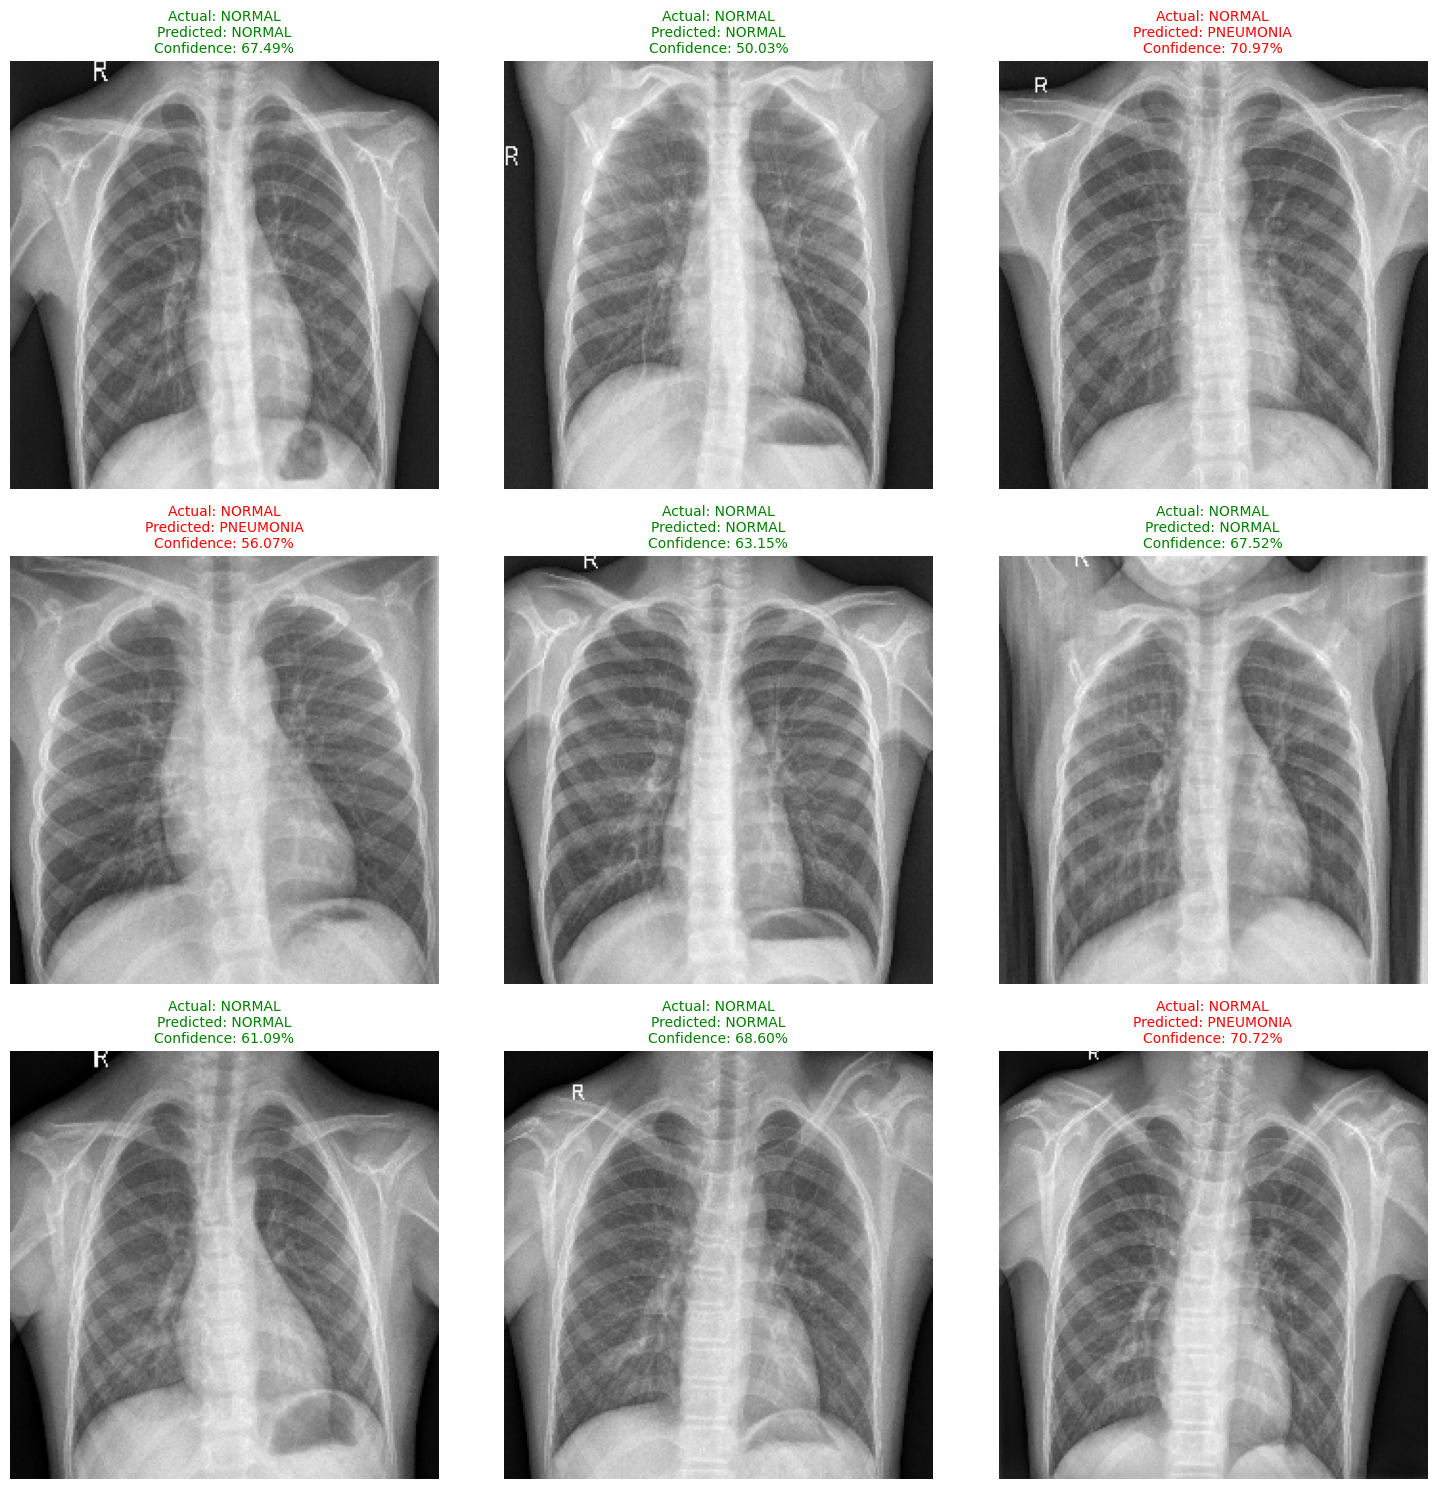

In [40]:
import matplotlib.pyplot as plt

# Display 9 sample predictions
plt.figure(figsize=(15, 15))

for i in range(9):
    plt.subplot(3, 3, i + 1)

    # Display image
    plt.imshow(images[i])
    plt.axis('off')

    # Actual label
    actual = "PNEUMONIA" if true_labels[i] == 1 else "NORMAL"

    # Predicted label
    predicted = "PNEUMONIA" if predicted_labels[i] == 1 else "NORMAL"

    # Confidence score
    confidence = confidence_scores[i] * 100

    # Green if correct, Red if incorrect
    color = "green" if actual == predicted else "red"

    plt.title(
        f"Actual: {actual}\n"
        f"Predicted: {predicted}\n"
        f"Confidence: {confidence:.2f}%",
        color=color,
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [41]:
for layer in model.layers:
    print(layer.name)

densenet121
global_average_pooling2d
dropout
dense
